<a href="https://colab.research.google.com/github/padaliyaabhay27/Monk9tech_VLSI_Internship_Task/blob/main/vlsi_asic_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LibreLane Colab

In [4]:
# @title Setup Nix {display-mode: "form"}
# @markdown <img src="https://raw.githubusercontent.com/NixOS/nixos-artwork/51a27e4a011e95cb559e37d32c44cf89b50f5154/logo/nix-snowflake-colours.svg" width="32"/>
# @markdown
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown and it is the primary method for installing LibreLane.
# @markdown
# @markdown This step installs the Nix package manager and enables the
# @markdown FOSSi Foundation Nix Cache.
# @markdown
# @markdown If you're not in a Colab, this just sets the environment variables.
# @markdown You will need to install Nix and enable flakes on your own following
# @markdown [this guide](https://librelane.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
from pathlib import Path
import subprocess
import sys
import shutil
import tempfile

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            d = Path(d)
            installer_path = d / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                [
                    "bash",
                    installer_path,
                    "install",
                    "--prefer-upstream-nix",
                    "--no-confirm",
                    "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\nextra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

In [5]:
# @title Get LibreLane {display-mode: "form"}
# @markdown Click the ▷ button to download and install LibreLane.
# @markdown
# @markdown This will install LibreLane's tool dependencies using Nix,
# @markdown and LibreLane itself using PIP.
# @markdown
# @markdown Note that `python3-tk` may need to be installed using your OS's
# @markdown package manager.
import os
import yaml
import subprocess
import IPython

librelane_version = "latest"  # @param {key:"LibreLane Version", type:"string"}

if librelane_version == "latest":
    librelane_version = "main"

pdk_root = "~/.ciel"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")

display(IPython.display.HTML("<h3>Downloading LibreLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {librelane_ipynb_path}
!mkdir -p {librelane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {librelane_ipynb_path}
else:
    !curl -L "https://github.com/librelane/librelane/tarball/{librelane_version}" | tar -xzC {librelane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading LibreLane's dependencies…</a>"))
try:
    with subprocess.Popen(
        [
            "nix",
            "profile",
            "install",
            ".#colab-env",
        ],
        cwd=librelane_ipynb_path,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        encoding="utf8",
    ) as p:
        for line in p.stdout:
            print(line, end="")
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=librelane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import ciel
from ciel.source import StaticWebDataSource

with open(
    os.path.join(librelane_ipynb_path, "librelane", "pdk_hashes.yaml"), "r"
) as file:
    pdk_hashes = yaml.safe_load(file)

ciel.enable(
    ciel.get_ciel_home(pdk_root),
    pdk,
    pdk_hashes[pdk],
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

sys.path.insert(0, librelane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 8901k    0 8901k    0     0  7476k      0 --:--:--  0:00:01 --:--:-- 9503k


Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 enabled for the sky130 PDK.

In [6]:
import librelane

print(librelane.__version__)

3.0.3


#Creating the design

In [7]:
%%writefile spm.v
module spm(clk, rst, x, y, p);
    parameter size = 32;
    input clk, rst;
    input y;
    input[size-1:0] x;
    output p;

    wire[size-1:1] pp;
    wire[size-1:0] xy;

    genvar i;

    CSADD csa0 (.clk(clk), .rst(rst), .x(x[0]&y), .y(pp[1]), .sum(p));
    generate for(i=1; i<size-1; i=i+1) begin
        CSADD csa (.clk(clk), .rst(rst), .x(x[i]&y), .y(pp[i+1]), .sum(pp[i]));
    end endgenerate
    TCMP tcmp (.clk(clk), .rst(rst), .a(x[size-1]&y), .s(pp[size-1]));

endmodule

module TCMP(clk, rst, a, s);
    input clk, rst;
    input a;
    output reg s;

    reg z;

    always @(posedge clk or posedge rst) begin
        if (rst) begin
            //Reset logic goes here.
            s <= 1'b0;
            z <= 1'b0;
        end
        else begin
            //Sequential logic goes here.
            z <= a | z;
            s <= a ^ z;
        end
    end
endmodule

module CSADD(clk, rst, x, y, sum);
    input clk, rst;
    input x, y;
    output reg sum;

    reg sc;

    // Half Adders logic
    wire hsum1, hco1;
    assign hsum1 = y ^ sc;
    assign hco1 = y & sc;

    wire hsum2, hco2;
    assign hsum2 = x ^ hsum1;
    assign hco2 = x & hsum1;

    always @(posedge clk or posedge rst) begin
        if (rst) begin
            //Reset logic goes here.
            sum <= 1'b0;
            sc <= 1'b0;
        end
        else begin
            //Sequential logic goes here.
            sum <= hsum2;
            sc <= hco1 ^ hco2;
        end
    end
endmodule

Writing spm.v


#Setting up the configuration

In [8]:
from librelane.config import Config

Config.interactive(
    "spm",
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=10,
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_CDLS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/cdl/sky130_fd_sc_hd.cdl
CELL_GDS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_20_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_40_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_60_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_80_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_2.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 10
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
DECAP_CELLS:
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: spm
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_CDLS: null
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC: /content/librelane_ipynb/librelane/scripts/base.sdc
FILL_CELLS:
- sky130_fd_sc_hd__fill_2
- sky130_fd_sc_hd__fill_1
GND_NETS: null
GND_PIN: VGND
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PAD_BONDPAD_HEIGHT: null
PAD_BONDPAD_NAME: null
PAD_BONDPAD_OFFSETS: null
PAD_BONDPAD_WIDTH: null
PAD_CDLS: null
PAD_CORNER: null
PAD_CORNER_SITE_NAME: null
PAD_EDGE_SPACING: 0
PAD_FAKE_SITES: null
PAD_FILLERS: null
PAD_GDS: null
PAD_LEFS: null
PAD_LIBS: null
PAD_PLACE_IO_TERMINALS: null
PAD_SITE_NAME: null
PAD_SPICE_MODELS: null
PAD_VERILOG_MODELS: null
PDK: sky130A
PDK_ROOT: /root/.ciel
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
meta:
  flow: null
  librelane_version: 3.0.3
  step: null
  substituting_steps: null
  version: 1

```


#Running implementation steps

In [9]:
from librelane.steps import Step

In [10]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()



### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

Note that Yosys steps do not currently support gzipped standard cell dotlib
files. They are however supported for macros:

https://github.com/YosysHQ/yosys/issues/4830

```

#### Importing
```python
from librelane.steps.pyosys import Synthesis

# or

from librelane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |


#### Configuration Variables

| Variable Name | Type | Description | Default | 
| - | - | - | - | 
| `SYNTH_LATCH_MAP` <sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |
| `SYNTH_TRISTATE_MAP` <sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |
| `SYNTH_CSA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |
| `SYNTH_RCA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |
| `SYNTH_FA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |
| `SYNTH_MUX_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |
| `SYNTH_MUX4_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |
| `SYNTH_CLOCKGATE_MIN_WIDTH`  | int? | If set to a value, a group of flip-flops with size >= SYNTH_CLOCKGATE_MIN_WIDTH and an enable signal are clock-gated instead. | `None` |
| `SYNTH_CLOCKGATE_POSEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `SYNTH_CLOCKGATE_NEGEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `YOSYS_LOG_LEVEL`  | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |
| `SYNTH_CORNER` <sup>PDK</sup> | str? | A fully qualified IPVT corner to use during synthesis. If unspecified, the value for `DEFAULT_CORNER` from the PDK will be used. | `None` |
| `SYNTH_SHOW`  | bool | Generate a graphviz DOT file for the design. This will fail on a completely empty design. | `False` |
| `SYNTH_CHECKS_ALLOW_TRISTATE`  | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |
| `SYNTH_AUTONAME`  | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |
| `SYNTH_STRATEGY`  | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |
| `SYNTH_ABC_BUFFERING`  | bool | Enables `abc` cell buffering. | `False` |
| `SYNTH_ABC_LEGACY_REFACTOR`  | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_LEGACY_REWRITE`  | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_DFF`  | bool | Passes D-flipflop cells through ABC for optimization (which can for example, eliminate identical flip-flops). | `False` |
| `SYNTH_ABC_USE_MFS3`  | bool | Experimental: attempts a SAT-based remapping in all area and delay strategies before 'retime', which may improve PPA results. | `False` |
| `SYNTH_ABC_AREA_USE_NF`  | bool | Experimental: uses the &nf delay-based mapper with a very high value instead of the amap area mapper, which may be better in some scenarios at recovering area. | `False` |
| `SYNTH_DIRECT_WIRE_BUFFERING`  | bool | Enables inserting buffer cells for directly connected wires. | `True` |
| `SYNTH_SPLITNETS`  | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |
| `SYNTH_SIZING`  | bool | Enables `abc` cell sizing (instead of buffering). | `False` |
| `SYNTH_HIERARCHY_MODE`  | 'flatten'｜<br />'deferred_flatten'｜<br />'keep' | Affects how hierarchy is maintained throughout and after synthesis. 'flatten' flattens it during and after synthesis. 'deferred_flatten' flattens it after synthesis. 'keep' never flattens it. Please note that when using the Slang plugin, you need to pass '--keep-hierarchy' to `SLANG_ARGUMENTS` separately. To keep the hierarchy partially, use one of the flattening options and set the 'keep_hierarchy' attribute on instances or modules via: `SYNTH_KEEP_HIERARCHY_INSTANCES`, `SYNTH_KEEP_HIERARCHY_MODULES` or `SYNTH_KEEP_HIERARCHY_MIN_COST`. | `flatten` |
| `SYNTH_KEEP_HIERARCHY_MIN_COST`  | int? | Sets the 'keep_hierarchy' attribute on modules where the gate count is estimated to exceed the specified threshold. This prevents larger modules from being flattened. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_INSTANCES`  | List[str]? | A list of instances for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_MODULES`  | List[str]? | A list of modules for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_SHARE_RESOURCES`  | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |
| `SYNTH_ADDER_TYPE`  | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |
| `SYNTH_EXTRA_MAPPING_FILE`  | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |
| `SYNTH_ELABORATE_ONLY`  | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |
| `SYNTH_MUL_BOOTH`  | bool | Runs the booth pass as part of synthesis: See https://yosyshq.readthedocs.io/projects/yosys/en/latest/cmd/booth.html | `False` |
| `SYNTH_TIE_UNDEFINED`  | 'high'｜<br />'low' | Whether to tie undefined values low or high. Explicitly provide null if you wish to simply leave them undriven. | `low` |
| `SYNTH_WRITE_NOATTR`  | bool | If true, Verilog-2001 attributes are omitted from output netlists. Some utilities do not support attributes. | `True` |
| `SYNTH_NORMALIZE_SINGLE_BIT_VECTORS`  | bool | If true, vectors with the shape [0:0] are converted to normal wires in the netlist. If disabled, even one-width pins will be suffixed [0] in the layout when imported by most PnR tools. | `True` |
| `VERILOG_FILES`  | List[Path] | The paths of the design's Verilog files. | `None` |
| `VERILOG_DEFINES`  | List[str]? | Preprocessor defines for input Verilog files. | `None` |
| `VERILOG_POWER_DEFINE`  | str? | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |
| `VERILOG_INCLUDE_DIRS`  | List[Path]? | Specifies the Verilog `include` directories. | `None` |
| `SYNTH_PARAMETERS`  | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |
| `USE_SLANG`  | bool | Use the Slang frontend to process files, which has better SystemVerilog parsing capabilities but is not as battle-tested as the default Yosys friend. | `False` |
| `SLANG_ARGUMENTS`  | List[str]? | Pass arguments to the Slang frontend. | `None` |



#Synthesis

In [11]:
from librelane.state import State

synthesis = Synthesis(
    VERILOG_FILES=["./spm.v"],
    state_in=State(),
)
synthesis.start()


──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[16:15:19] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/1-yosys-synthesis'…                    ]8;id=275615;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=823315;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:19] VERBOSE  Logging subprocess to 'librelane_run/1-yosys-synthesis/yosys-synthesis.log'…       ]8;id=955605;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=367407;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

101. Executing Verilog backend.

Dumping module `\spm'.

102. Executing JSON backend.

[16:15:26] VERBOSE  Parsing synthesis checks…                                                          ]8;id=219014;file:///content/librelane_ipynb/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=770177;file:///content/librelane_ipynb/librelane/steps/pyosys.py#59\59]8;;\

Format,Path
nl,librelane_run/1-yosys-synthesis/spm.nl.v


In [12]:
display(synthesis)

#### Time Elapsed: 7.27s
#### Views updated:
* Verilog Netlist


#Floorplanning

In [13]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[16:15:26] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/2-openroad-floorplan'…              ]8;id=102691;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=420909;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:27] VERBOSE  Logging subprocess to 'librelane_run/2-openroad-floorplan/openroad-floorplan.log'… ]8;id=660003;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=40232;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/2-openroad-floorplan/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/2-openroad-floorplan/spm.pnl.v'…

Writing layout to '/content/librelane_run/2-openroad-floorplan/spm.def'…

Writing timing constraints to '/content/librelane_run/2-openroad-floorplan/spm.sdc'…

Format,Path
nl,librelane_run/2-openroad-floorplan/spm.nl.v
odb,librelane_run/2-openroad-floorplan/spm.odb
def,librelane_run/2-openroad-floorplan/spm.def
sdc,librelane_run/2-openroad-floorplan/spm.sdc
pnl,librelane_run/2-openroad-floorplan/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:33] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_7yjybkui'…               ]8;id=977941;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=935674;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:33] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_7yjybkui/klayout-render.log'…  ]8;id=568096;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=17601;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 6.19s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
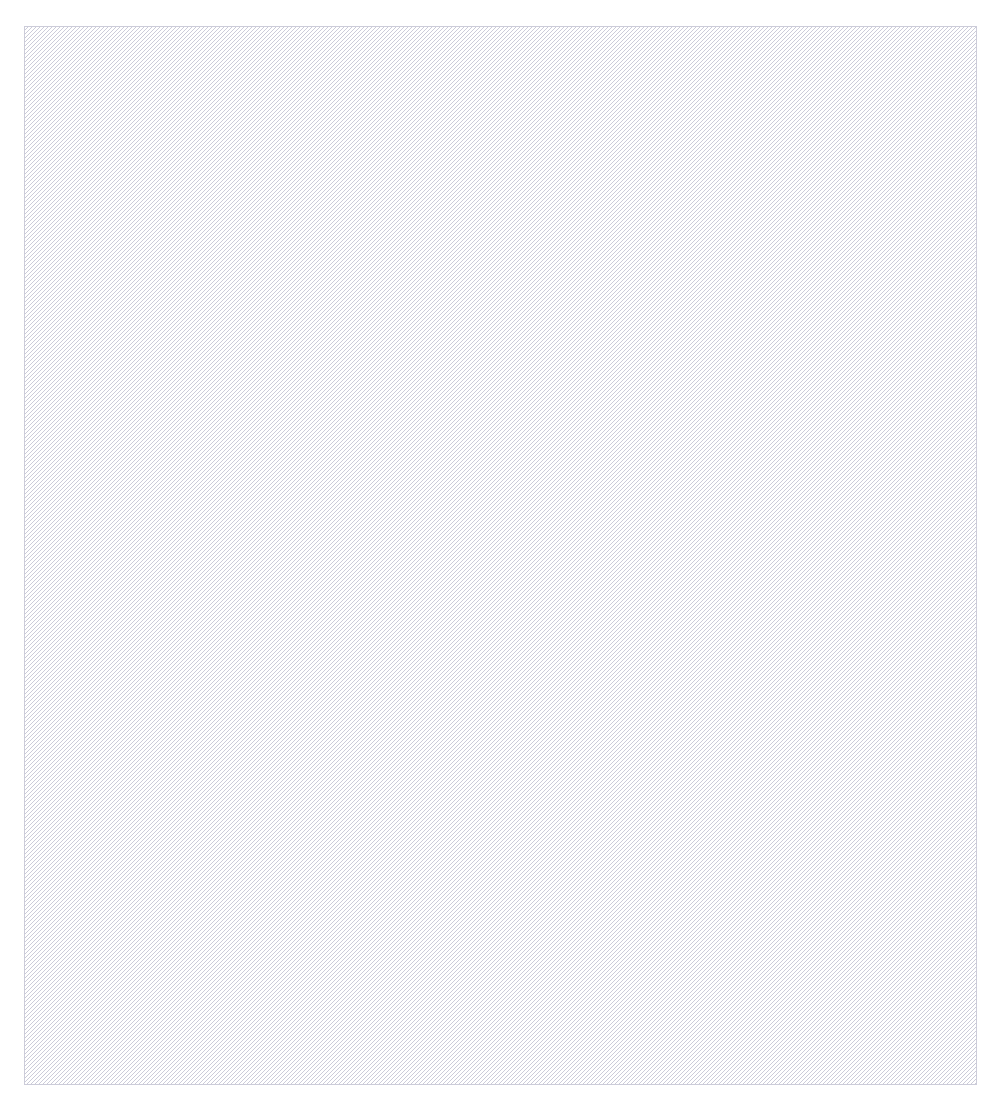

In [14]:
display(floorplan)

#Tap/Endcap Cell Insertion

In [15]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[16:15:35] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=62286;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=129217;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion'…                                                 

[16:15:35] VERBOSE  Logging subprocess to                                                              ]8;id=425879;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=956614;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                 

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.pnl.v'…

Writing layout to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.def'…

Writing timing constraints to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.sdc'…

Format,Path
nl,librelane_run/3-openroad-tapendcapinsertion/spm.nl.v
odb,librelane_run/3-openroad-tapendcapinsertion/spm.odb
def,librelane_run/3-openroad-tapendcapinsertion/spm.def
sdc,librelane_run/3-openroad-tapendcapinsertion/spm.sdc
pnl,librelane_run/3-openroad-tapendcapinsertion/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:37] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_9v8wqy5z'…               ]8;id=961798;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=827837;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:37] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_9v8wqy5z/klayout-render.log'…  ]8;id=83479;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=517957;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.65s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
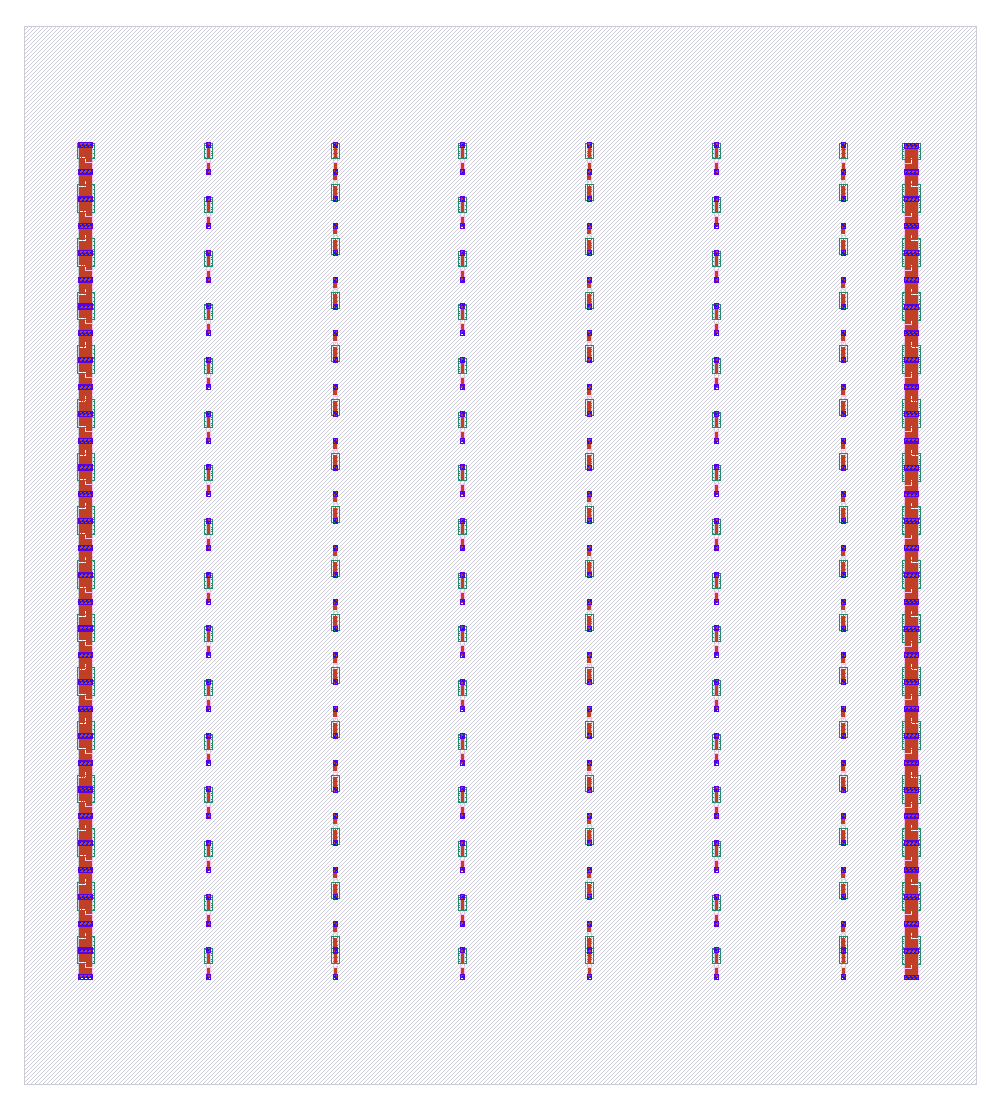

In [16]:
display(tdi)

#I/O Placement

In [17]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[16:15:38] VERBOSE  Running 'OpenROAD.IOPlacement' at 'librelane_run/4-openroad-ioplacement'…          ]8;id=477300;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=625906;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:38] VERBOSE  Logging subprocess to                                                              ]8;id=316089;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=44212;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/4-openroad-ioplacement/openroad-ioplacement.log'…                               

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/4-openroad-ioplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/4-openroad-ioplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/4-openroad-ioplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/4-openroad-ioplacement/spm.sdc'…

Format,Path
nl,librelane_run/4-openroad-ioplacement/spm.nl.v
odb,librelane_run/4-openroad-ioplacement/spm.odb
def,librelane_run/4-openroad-ioplacement/spm.def
sdc,librelane_run/4-openroad-ioplacement/spm.sdc
pnl,librelane_run/4-openroad-ioplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:39] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_lc8y1uts'…               ]8;id=907958;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=167483;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:39] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_lc8y1uts/klayout-render.log'…  ]8;id=772565;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=658629;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.03s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
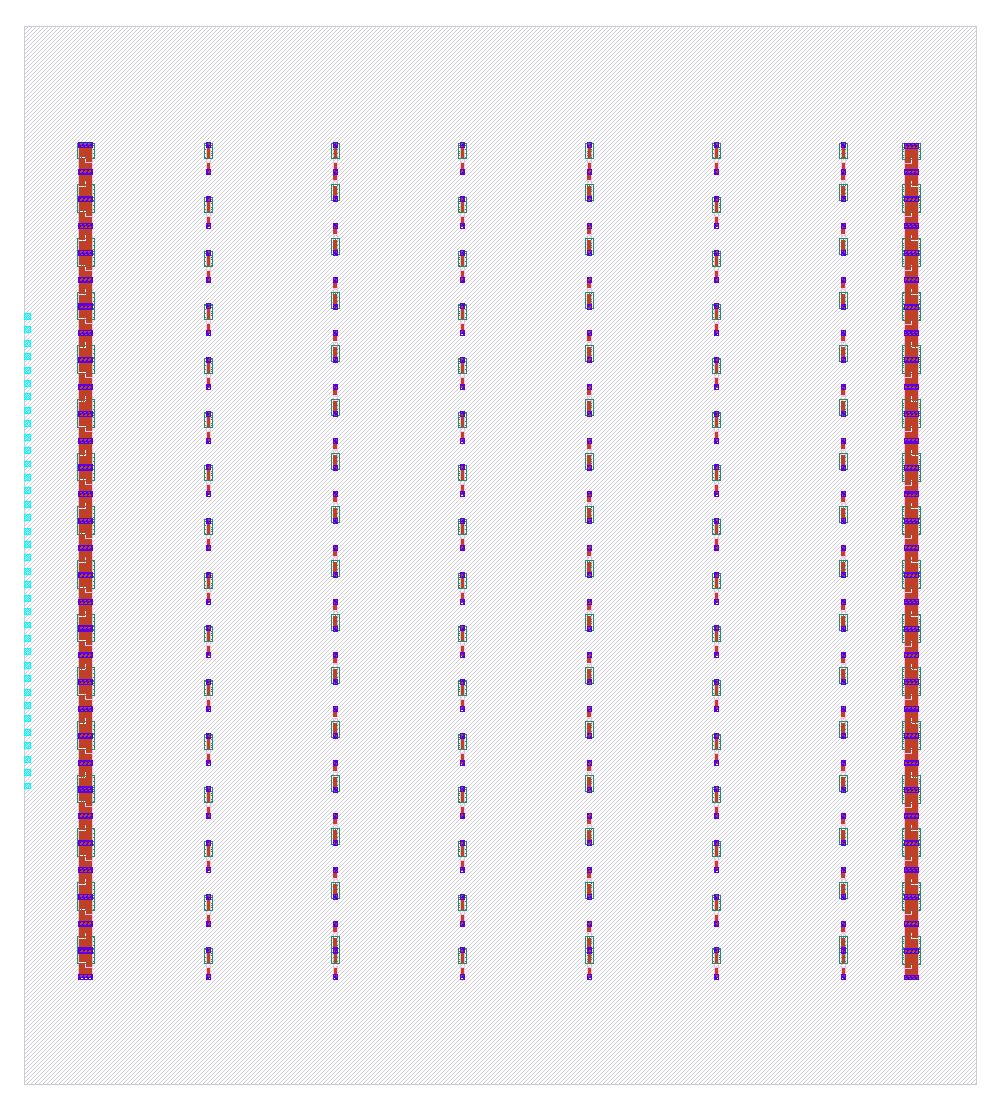

In [18]:
display(ioplace)

#Generating the Power Distribution Network (PDN)

In [19]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

[16:15:39] INFO     Loading the incremental configuration has generated the following warnings:       ]8;id=220716;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=48550;file:///content/librelane_ipynb/librelane/config/config.py#333\333]8;;\

[16:15:39] WARNING  The configuration variable 'FP_PDN_VWIDTH' is deprecated. Please check the docs   ]8;id=440599;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=490548;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VWIDTH'.                                        

[16:15:39] WARNING  The configuration variable 'FP_PDN_HWIDTH' is deprecated. Please check the docs   ]8;id=190558;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=900949;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HWIDTH'.                                        

[16:15:39] WARNING  The configuration variable 'FP_PDN_VPITCH' is deprecated. Please check the docs   ]8;id=74177;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=882581;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VPITCH'.                                        

[16:15:39] WARNING  The configuration variable 'FP_PDN_HPITCH' is deprecated. Please check the docs   ]8;id=739988;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=262903;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HPITCH'.                                        

...

Writing layout to '/content/librelane_run/5-openroad-generatepdn/spm.def'…

Writing timing constraints to '/content/librelane_run/5-openroad-generatepdn/spm.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,librelane_run/5-openroad-generatepdn/spm.nl.v
odb,librelane_run/5-openroad-generatepdn/spm.odb
def,librelane_run/5-openroad-generatepdn/spm.def
sdc,librelane_run/5-openroad-generatepdn/spm.sdc
pnl,librelane_run/5-openroad-generatepdn/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:41] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_2tz5fbuc'…               ]8;id=645660;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=461789;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:41] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_2tz5fbuc/klayout-render.log'…  ]8;id=678961;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=899228;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.23s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
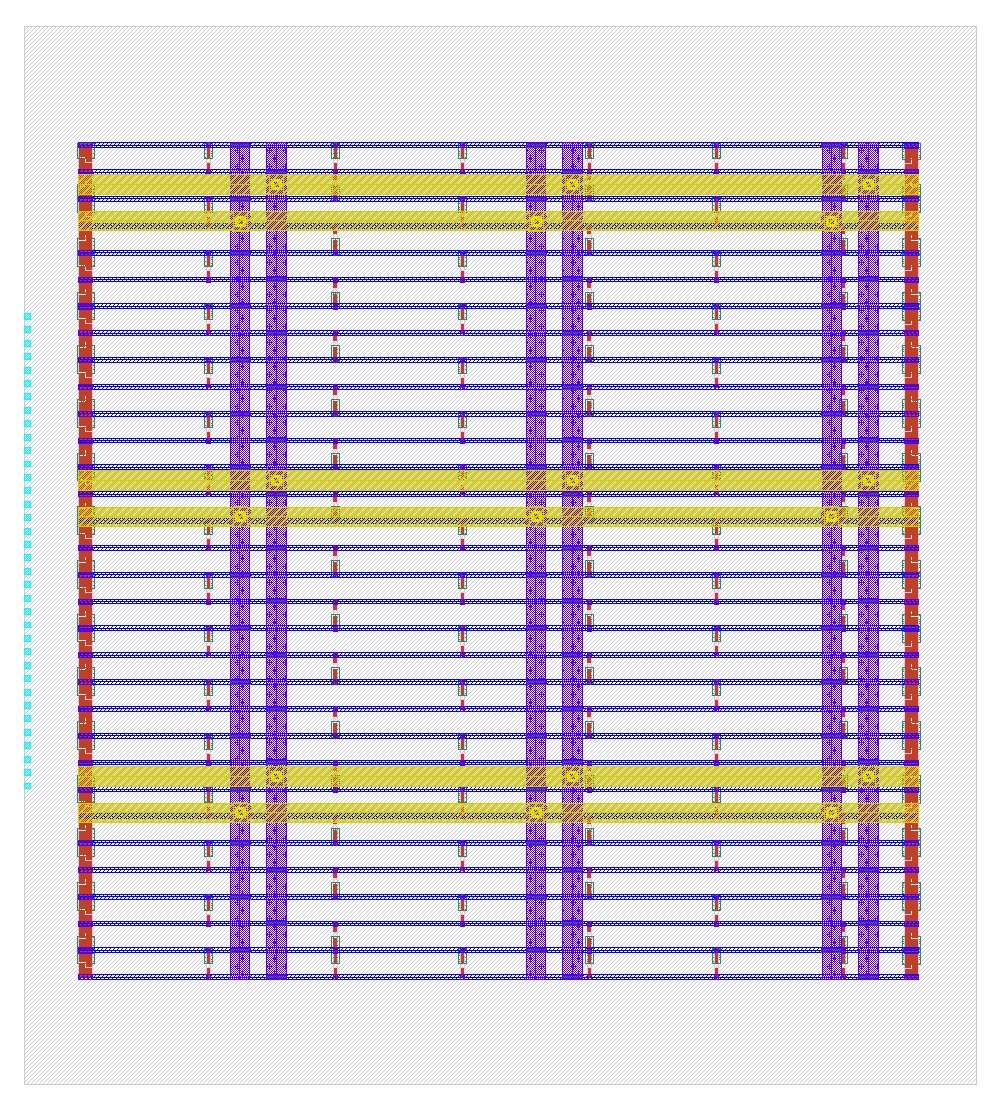

In [20]:
display(pdn)

#Global Placement

In [21]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[16:15:41] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/6-openroad-globalplacement'…  ]8;id=411141;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=960963;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:41] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=713778;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=837033;file:///content/librelane_ipynb/librelane/steps/openroad.py#1581\1581]8;;\
                    target density: 62.659100…                                                                     

[16:15:41] VERBOSE  Logging subprocess to                                                              ]8;id=430267;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=192636;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/6-openroad-globalplacement/openroad-globalplacement.log'…                       

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/6-openroad-globalplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/6-openroad-globalplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/6-openroad-globalplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/6-openroad-globalplacement/spm.sdc'…

Format,Path
nl,librelane_run/6-openroad-globalplacement/spm.nl.v
odb,librelane_run/6-openroad-globalplacement/spm.odb
def,librelane_run/6-openroad-globalplacement/spm.def
sdc,librelane_run/6-openroad-globalplacement/spm.sdc
pnl,librelane_run/6-openroad-globalplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:43] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_mcnlnqvh'…               ]8;id=787856;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=53276;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:43] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_mcnlnqvh/klayout-render.log'…  ]8;id=336738;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=433927;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.54s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
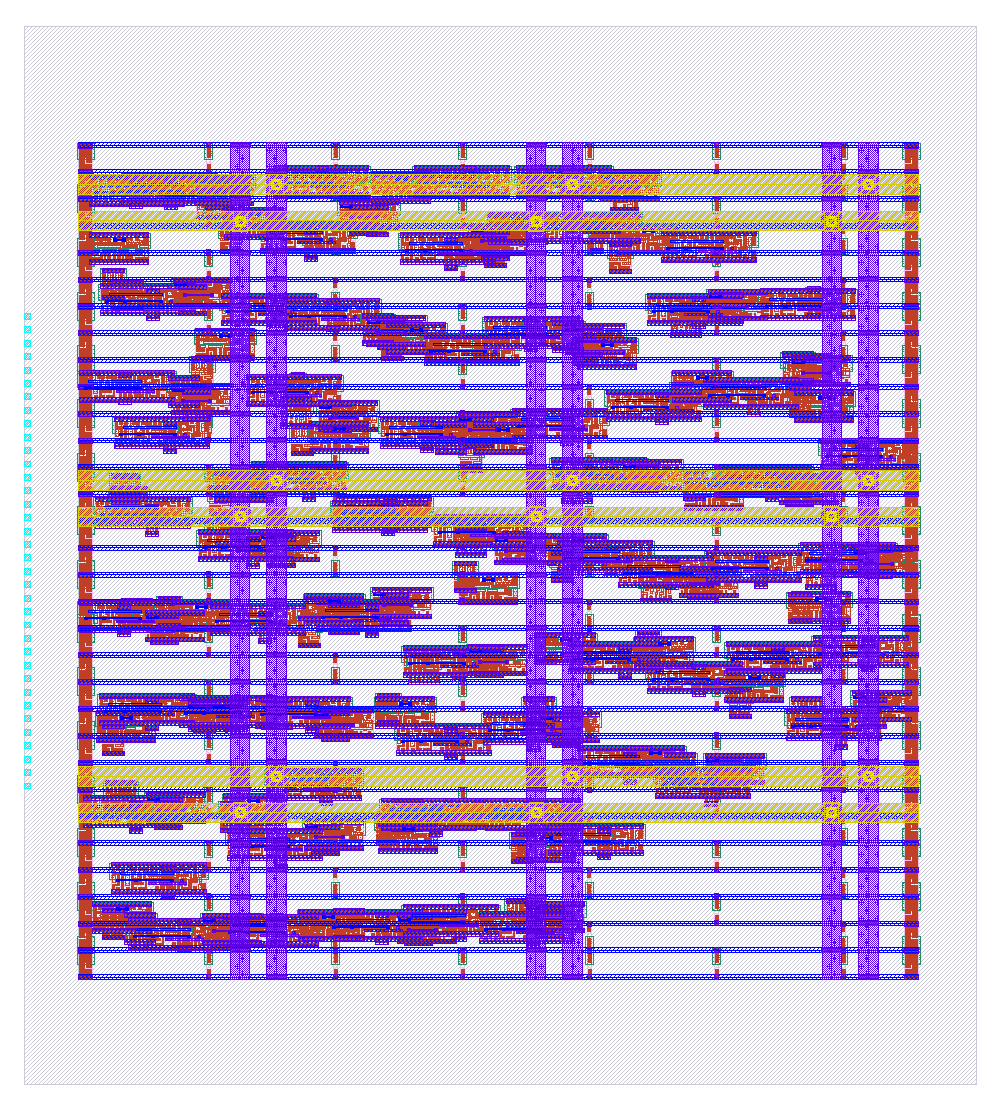

In [22]:
display(gpl)

#Detailed Placement

In [23]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[16:15:44] VERBOSE  Running 'OpenROAD.DetailedPlacement' at                                            ]8;id=79080;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=745527;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/7-openroad-detailedplacement'…                                                  

[16:15:44] VERBOSE  Logging subprocess to                                                              ]8;id=167;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=935971;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/7-openroad-detailedplacement/openroad-detailedplacement.log'…                   

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/7-openroad-detailedplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/7-openroad-detailedplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/7-openroad-detailedplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/7-openroad-detailedplacement/spm.sdc'…

Format,Path
nl,librelane_run/7-openroad-detailedplacement/spm.nl.v
odb,librelane_run/7-openroad-detailedplacement/spm.odb
def,librelane_run/7-openroad-detailedplacement/spm.def
sdc,librelane_run/7-openroad-detailedplacement/spm.sdc
pnl,librelane_run/7-openroad-detailedplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:15:46] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_2ujgrqe4'…               ]8;id=787579;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=668887;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:15:46] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_2ujgrqe4/klayout-render.log'…  ]8;id=174314;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=47133;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 2.09s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
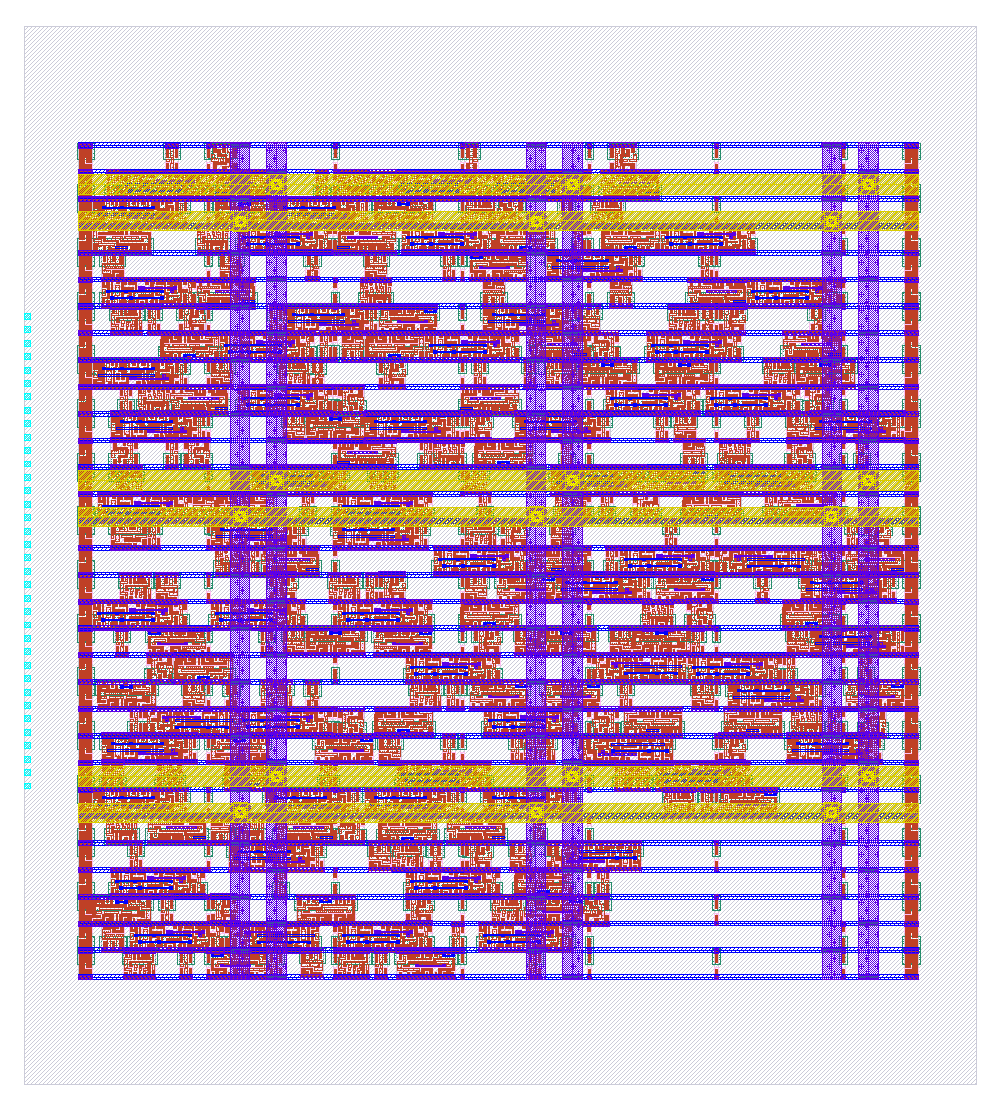

In [24]:
display(dpl)

#Clock Tree Synthesis (CTS)

In [27]:
CTS = Step.factory.get("OpenROAD.CTS")

cts = CTS(state_in=dpl.state_out)
cts.start()


────────────────────────────────────────────── Clock Tree Synthesis ───────────────────────────────────────────────

[16:18:53] VERBOSE  Running 'OpenROAD.CTS' at 'librelane_run/9-openroad-cts'…                          ]8;id=272630;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=157616;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:18:54] VERBOSE  Logging subprocess to 'librelane_run/9-openroad-cts/openroad-cts.log'…             ]8;id=277562;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=378631;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner max_tt_025C_1v80…

Reading timing library for the 'max_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/9-openroad-cts/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/9-openroad-cts/spm.pnl.v'…

Writing layout to '/content/librelane_run/9-openroad-cts/spm.def'…

Writing timing constraints to '/content/librelane_run/9-openroad-cts/spm.sdc'…

Format,Path
nl,librelane_run/9-openroad-cts/spm.nl.v
odb,librelane_run/9-openroad-cts/spm.odb
def,librelane_run/9-openroad-cts/spm.def
sdc,librelane_run/9-openroad-cts/spm.sdc
pnl,librelane_run/9-openroad-cts/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:18:53] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_lms_gp7j'…               ]8;id=345528;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=23702;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:18:53] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_lms_gp7j/klayout-render.log'…  ]8;id=797737;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=371727;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 19.60s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
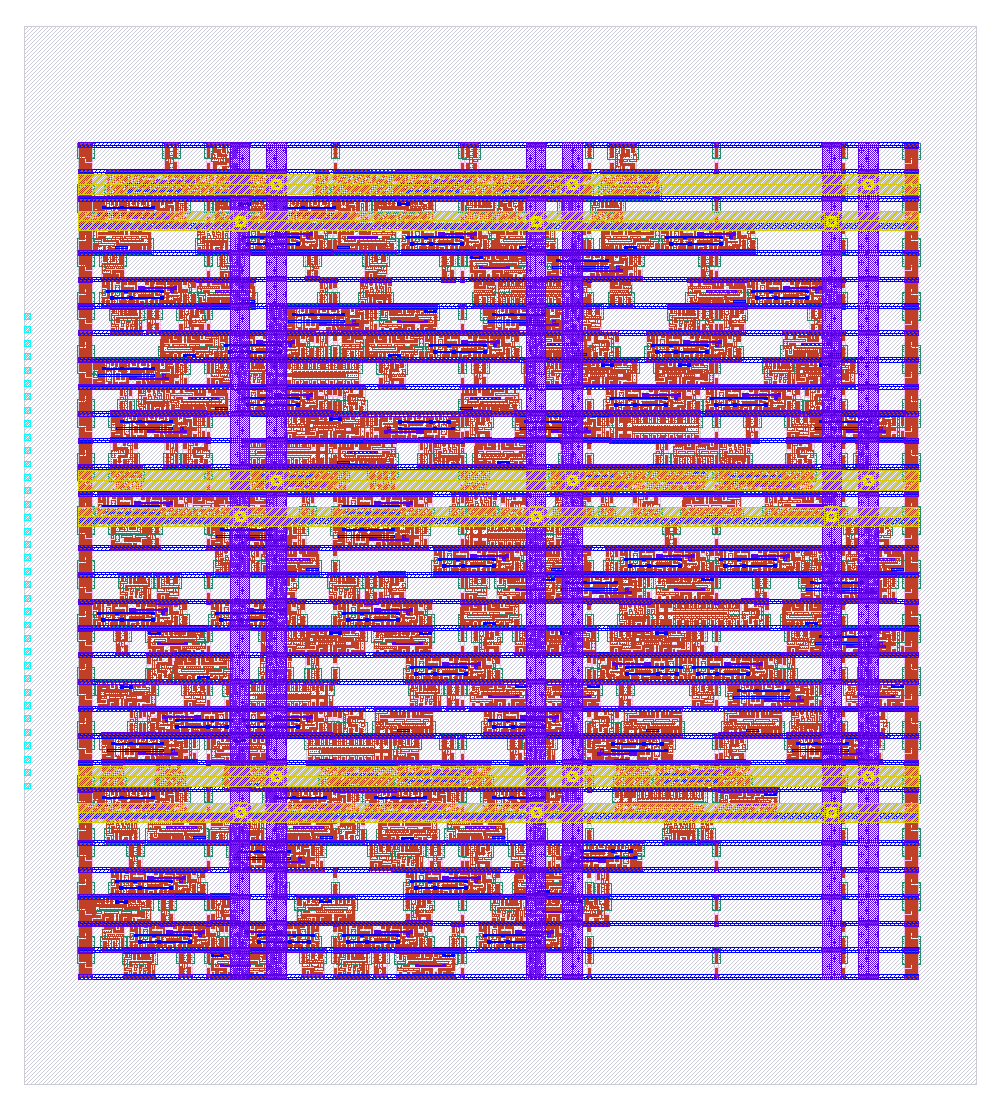

In [26]:
display(cts)

#Global Routing

In [28]:
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")

grt = GlobalRouting(state_in=cts.state_out)
grt.start()

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[16:19:56] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'librelane_run/10-openroad-globalrouting'…     ]8;id=694840;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=355785;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:19:56] VERBOSE  Logging subprocess to                                                              ]8;id=641780;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=829476;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/10-openroad-globalrouting/openroad-globalrouting.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Multi-Input combinational cell          158    1732.91

Total                                   456    4236.56

Writing OpenROAD database to '/content/librelane_run/10-openroad-globalrouting/spm.odb'…

Writing layout to '/content/librelane_run/10-openroad-globalrouting/spm.def'…

Format,Path
nl,librelane_run/9-openroad-cts/spm.nl.v
odb,librelane_run/10-openroad-globalrouting/spm.odb
def,librelane_run/10-openroad-globalrouting/spm.def
sdc,librelane_run/9-openroad-cts/spm.sdc
pnl,librelane_run/9-openroad-cts/spm.pnl.v


#Detailed Routing

In [29]:
DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")

drt = DetailedRouting(state_in=grt.state_out)
drt.start()

──────────────────────────────────────────────── Detailed Routing ─────────────────────────────────────────────────

[16:20:41] VERBOSE  Running 'OpenROAD.DetailedRouting' at 'librelane_run/11-openroad-detailedrouting'… ]8;id=554179;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=328778;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:20:41] INFO     Running TritonRoute with 2 threads…                                            ]8;id=335010;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=502048;file:///content/librelane_ipynb/librelane/steps/openroad.py#2002\2002]8;;\

[16:20:41] VERBOSE  Logging subprocess to                                                              ]8;id=471122;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=314773;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/11-openroad-detailedrouting/openroad-detailedrouting.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/11-openroad-detailedrouting/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/11-openroad-detailedrouting/spm.pnl.v'…

Writing layout to '/content/librelane_run/11-openroad-detailedrouting/spm.def'…

Writing timing constraints to '/content/librelane_run/11-openroad-detailedrouting/spm.sdc'…

Format,Path
nl,librelane_run/11-openroad-detailedrouting/spm.nl.v
odb,librelane_run/11-openroad-detailedrouting/spm.odb
def,librelane_run/11-openroad-detailedrouting/spm.def
sdc,librelane_run/11-openroad-detailedrouting/spm.sdc
pnl,librelane_run/11-openroad-detailedrouting/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:22:44] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_poihu3m4'…               ]8;id=236984;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=30972;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:22:44] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_poihu3m4/klayout-render.log'…  ]8;id=549322;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=180533;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 123.36s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
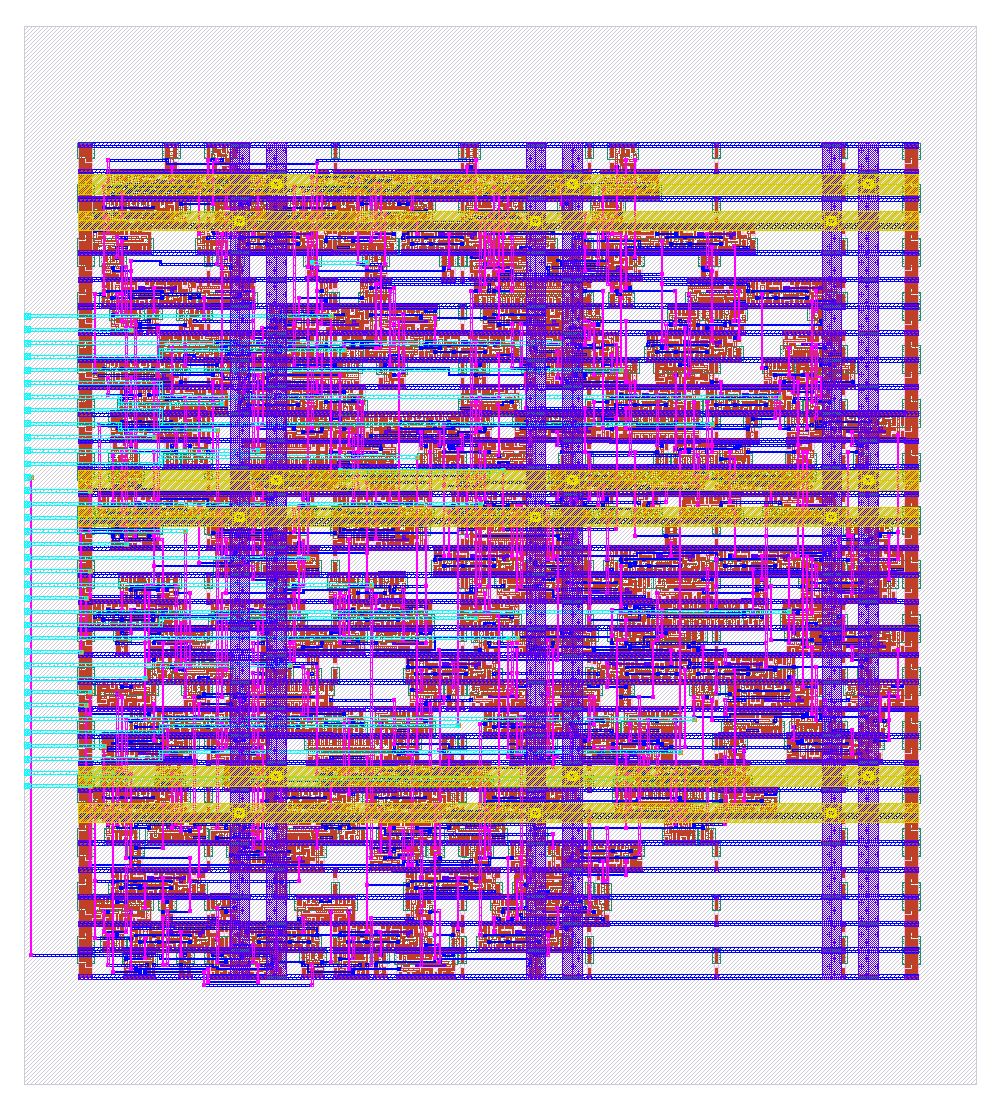

In [30]:
display(drt)

#Fill Insertion

In [31]:
FillInsertion = Step.factory.get("OpenROAD.FillInsertion")

fill = FillInsertion(state_in=drt.state_out)
fill.start()


───────────────────────────────────────────────── Fill Insertion ──────────────────────────────────────────────────

[16:22:45] VERBOSE  Running 'OpenROAD.FillInsertion' at 'librelane_run/12-openroad-fillinsertion'…     ]8;id=81559;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=31215;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:22:45] VERBOSE  Logging subprocess to                                                              ]8;id=126719;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=400565;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/12-openroad-fillinsertion/openroad-fillinsertion.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'…

Writing layout to '/content/librelane_run/12-openroad-fillinsertion/spm.def'…

Writing timing constraints to '/content/librelane_run/12-openroad-fillinsertion/spm.sdc'…

Format,Path
nl,librelane_run/12-openroad-fillinsertion/spm.nl.v
odb,librelane_run/12-openroad-fillinsertion/spm.odb
def,librelane_run/12-openroad-fillinsertion/spm.def
sdc,librelane_run/12-openroad-fillinsertion/spm.sdc
pnl,librelane_run/12-openroad-fillinsertion/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:22:46] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_0gsvstc_'…               ]8;id=131397;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=879412;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:22:46] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_0gsvstc_/klayout-render.log'…  ]8;id=708288;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=197748;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.02s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
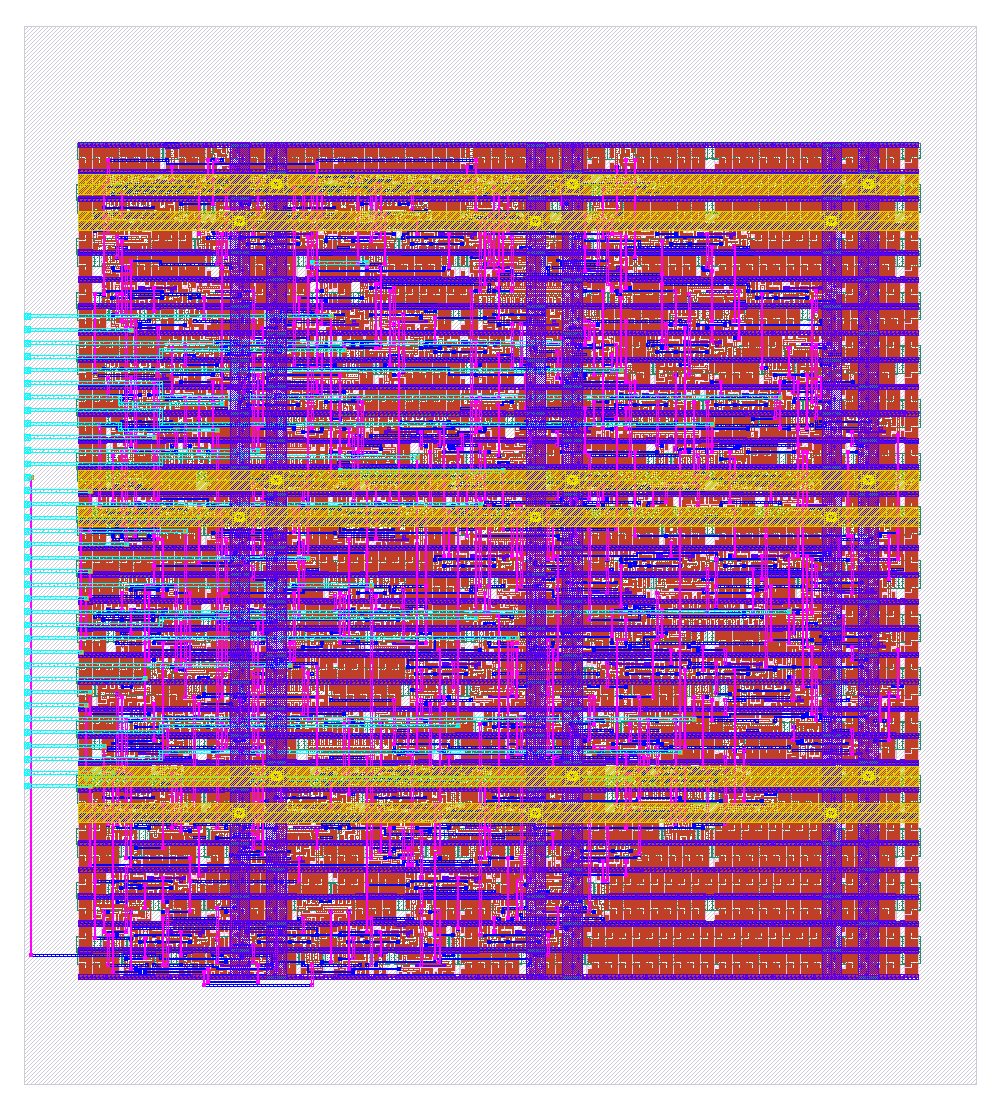

In [32]:
display(fill)

#Parasitics Extraction a.k.a. Resistance/Capacitance Extraction (RCX)

In [33]:
RCX = Step.factory.get("OpenROAD.RCX")

rcx = RCX(state_in=fill.state_out)
rcx.start()

─────────────────────────────────── Parasitic Resistance/Capacitance Extraction ───────────────────────────────────

[16:22:57] VERBOSE  Running 'OpenROAD.RCX' at 'librelane_run/13-openroad-rcx'…                         ]8;id=155618;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=559799;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:22:57] INFO     Running RCX for corners matching nom_*                                         ]8;id=225270;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=997406;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/13-openroad-rcx/nom/rcx.log)…                                          

[16:22:57] INFO     Running RCX for corners matching min_*                                         ]8;id=141083;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=239301;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/13-openroad-rcx/min/rcx.log)…                                          

[16:22:57] VERBOSE  Logging subprocess to 'librelane_run/13-openroad-rcx/nom/rcx.log'…                 ]8;id=168085;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=318263;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

...

[16:22:58] INFO     Running RCX for corners matching max_*                                         ]8;id=288127;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=558261;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/13-openroad-rcx/max/rcx.log)…                                          

[16:22:58] INFO     Finished RCX for corners matching min_*.                                       ]8;id=390581;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=946837;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

[16:22:58] VERBOSE  Logging subprocess to 'librelane_run/13-openroad-rcx/max/rcx.log'…                 ]8;id=205182;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=303116;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[16:22:59] INFO     Finished RCX for corners matching max_*.                                       ]8;id=90251;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=561155;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__count__class:sequential_cell': 64, 'design__instance__area__class:sequential_cell': Decimal('1681.61'), 'design__instance__count__class:multi_input_combinational_cell': 158, 'design__instance__area__class:multi_input_combinational_cell': Decimal('1732.91'), 'flow__warnings__count': 0, 'flow__errors__count': 0, 'flow__warnings__count:ODB-0220': 2, 'flow__warnings__type_count': 0, 'design__instance__count__class:fill_cell': 950, 'design__instance__area__class:fill_cell': Decimal('3171.79'), 'design__instance__count__class:tap_cell': 99, 'design__instance__area__class:tap_cell': Decimal('123.869'), 'floorplan__design__io': 36, 'design__io__hpwl': 2178252, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count': 0, 'design__instance__displacement__total': Decimal('80.827'), 'design__instance__displacement__mean': Decimal('0.177'), 'design__instance__displacement__max': Decimal('5.52'), 'route__wirelength__estimated': Decimal('5082.65'), 'design__violations': 0, 'design__instance__count__class:clock_buffer': 9, 'design__instance__area__class:clock_buffer': Decimal('225.216'), 'flow__warnings__count:STA-1140': 6, 'global_route__vias': 1916, 'global_route__wirelength': 9901, 'route__net': 330, 'route__net__special': 2, 'route__drc_errors__iter:0': 67, 'route__wirelength__iter:0': 5902, 'route__drc_errors__iter:1': 5, 'route__wirelength__iter:1': 5863, 'route__drc_errors__iter:2': 1, 'route__wirelength__iter:2': 5847, 'route__drc_errors__iter:3': 1, 'route__wirelength__iter:3': 5853, 'route__drc_errors__iter:4': 0, 'route__wirelength__iter:4': 5843, 'route__drc_errors': 0, 'route__wirelength': 5843, 'route__vias': 1831, 'route__vias__singlecut': 1831, 'route__vias__multicut': 0, 'antenna__violating__nets': 0, 'antenna__violating__pins': 0, 'flow__warnings__count:DRT-0349': 10}}

#Static Timing Analysis (Post-PnR)

In [34]:
STAPostPNR = Step.factory.get("OpenROAD.STAPostPNR")

sta_post_pnr = STAPostPNR(state_in=rcx.state_out)
sta_post_pnr.start()

──────────────────────────────────────── Static Timing Analysis (Post-PnR) ────────────────────────────────────────

[16:22:59] VERBOSE  Running 'OpenROAD.STAPostPNR' at 'librelane_run/14-openroad-stapostpnr'…           ]8;id=104290;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=711062;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:22:59] INFO     Starting STA for the nom_tt_025C_1v80 timing corner…                            ]8;id=494274;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=617000;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[16:22:59] INFO     Starting STA for the nom_ss_100C_1v60 timing corner…                            ]8;id=377820;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=588313;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[16:22:59] VERBOSE  Logging subprocess to                                                              ]8;id=189697;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=535214;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/sta.log'…                               

...

[16:23:14] INFO     Finished STA for the max_ff_n40C_1v95 timing corner.                            ]8;id=142619;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=914165;file:///content/librelane_ipynb/librelane/steps/openroad.py#762\762]8;;\

[16:23:14] VERBOSE  Logging subprocess to                                                              ]8;id=664468;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=667433;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log'…                

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┓
┃                      ┃       ┃       ┃      ┃       ┃ of   ┃       ┃      ┃       ┃      ┃ of    ┃      ┃       ┃
┃                      ┃       ┃ Reg   ┃      ┃       ┃ whi… ┃       ┃ Reg  ┃       ┃      ┃ which ┃      ┃       ┃
┃                      ┃ Hold  ┃ to    ┃      ┃ Hold  ┃ reg  ┃ Setup ┃ to   ┃       ┃ Set… ┃ reg   ┃ Max  ┃ Max   ┃
┃                      ┃ Worst ┃ Reg   ┃ Hold ┃ Vio   ┃ to   ┃ Worst ┃ Reg  ┃ Setup ┃ Vio  ┃ to    ┃ Cap  ┃ Slew  ┃
┃ Corner/Group         ┃ Slack ┃ Paths ┃ TNS  ┃ Count ┃ reg  ┃ Slack ┃ Pat… ┃ TNS   ┃ Cou… ┃ reg   ┃ Vio… ┃ Viol… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━┩
│ Overall              │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 5.62… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ nom_tt_025C_1v80     │ 0.23… │ 0.23… │ 0.0… │ 0     │ 0    │ 6.72… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ nom_ss_100C_1v60     │ 0.71… │ 0.71… │ 0.0… │ 0     │ 0    │ 5.65… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ nom_ff_n40C_1v95     │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 7.08… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ min_tt_025C_1v80     │ 0.23… │ 0.23… │ 0.0… │ 0     │ 0    │ 6.75… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ min_ss_100C_1v60     │ 0.71… │ 0.71… │ 0.0… │ 0     │ 0    │ 5.69… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ min_ff_n40C_1v95     │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 7.10… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ max_tt_025C_1v80     │ 0.23… │ 0.23… │ 0.0… │ 0     │ 0    │ 6.68… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ max_ss_100C_1v60     │ 0.72… │ 0.72… │ 0.0… │ 0     │ 0    │ 5.62… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
│ max_ff_n40C_1v95     │ 0.05… │ 0.05… │ 0.0… │ 0     │ 0    │ 7.05… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 130   │
└──────────────────────┴───────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┘

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                      ┃ Hold     ┃ Reg to   ┃          ┃          ┃ of which  ┃ Setup    ┃           ┃          ┃           ┃ of which ┃           ┃          ┃
┃                      ┃ Worst    ┃ Reg      ┃          ┃ Hold Vio ┃ reg to    ┃ Worst    ┃ Reg to    ┃ Setup    ┃ Setup Vio ┃ reg to   ┃ Max Cap   ┃ Max Slew ┃
┃ Corner/Group         ┃ Slack    ┃ Paths    ┃ Hold TNS ┃ Count    ┃ reg       ┃ Slack    ┃ Reg Paths ┃ TNS      ┃ Count     ┃ reg      ┃ Violatio… ┃ Violati… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ Overall              │ 0.0509   │ 0.0509   │ 0.0000   │ 0        │ 0         │ 5.6215   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ nom_tt_025C_1v80     │ 0.2319   │ 0.2319   │ 0.0000   │ 0        │ 0         │ 6.7266   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ nom_ss_100C_1v60     │ 0.7169   │ 0.7169   │ 0.0000   │ 0        │ 0         │ 5.6536   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ nom_ff_n40C_1v95     │ 0.0518   │ 0.0518   │ 0.0000   │ 0        │ 0         │ 7.0865   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ min_tt_025C_1v80     │ 0.2305   │ 0.2305   │ 0.0000   │ 0        │ 0         │ 6.7550   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ min_ss_100C_1v60     │ 0.7147   │ 0.7147   │ 0.0000   │ 0        │ 0         │ 5.6931   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ min_ff_n40C_1v95     │ 0.0509   │ 0.0509   │ 0.0000   │ 0        │ 0         │ 7.1083   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ max_tt_025C_1v80     │ 0.2338   │ 0.2338   │ 0.0000   │ 0        │ 0         │ 6.6865   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ max_ss_100C_1v60     │ 0.7200   │ 0.7200   │ 0.0000   │ 0        │ 0         │ 5.6215   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
│ max_ff_n40C_1v95     │ 0.0532   │ 0.0532   │ 0.0000   │ 0        │ 0         │ 7.0557   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 130      │
└──────────────────────┴──────────┴──────────┴──────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┘

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__count__class:sequential_cell': 64, 'design__instance__area__class:sequential_cell': Decimal('1681.61'), 'design__instance__count__class:multi_input_combinational_cell': 158, 'design__instance__area__class:multi_input_combinational

#Stream-out

In [35]:
StreamOut = Step.factory.get("KLayout.StreamOut")

gds = StreamOut(state_in=sta_post_pnr.state_out)
gds.start()

─────────────────────────────────────────── GDSII Stream Out (KLayout) ────────────────────────────────────────────

[16:23:15] VERBOSE  Running 'KLayout.StreamOut' at 'librelane_run/15-klayout-streamout'…               ]8;id=417159;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=281127;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:23:15] VERBOSE  Logging subprocess to 'librelane_run/15-klayout-streamout/klayout-streamout.log'…  ]8;id=482880;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=472216;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[INFO] Clearing cells…

[INFO] Merging GDS files…

...

[INFO] Checking for missing GDS…

[INFO] All LEF cells have matching GDS cells.

[INFO] Writing out GDS '/content/librelane_run/15-klayout-streamout/spm.klayout.gds'…

[INFO] Done.

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/15-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/15-klayout-streamout/spm.gds'), 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__count__class:sequential_cell': 64, 'design__instance__area__class:sequential_c

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[16:23:16] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_x9he9aey'…               ]8;id=904135;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=213838;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:23:16] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_x9he9aey/klayout-render.log'…  ]8;id=146024;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=105743;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.62s
#### Views updated:
* GDSII Stream (KLayout)
* GDSII Stream
#### Preview:
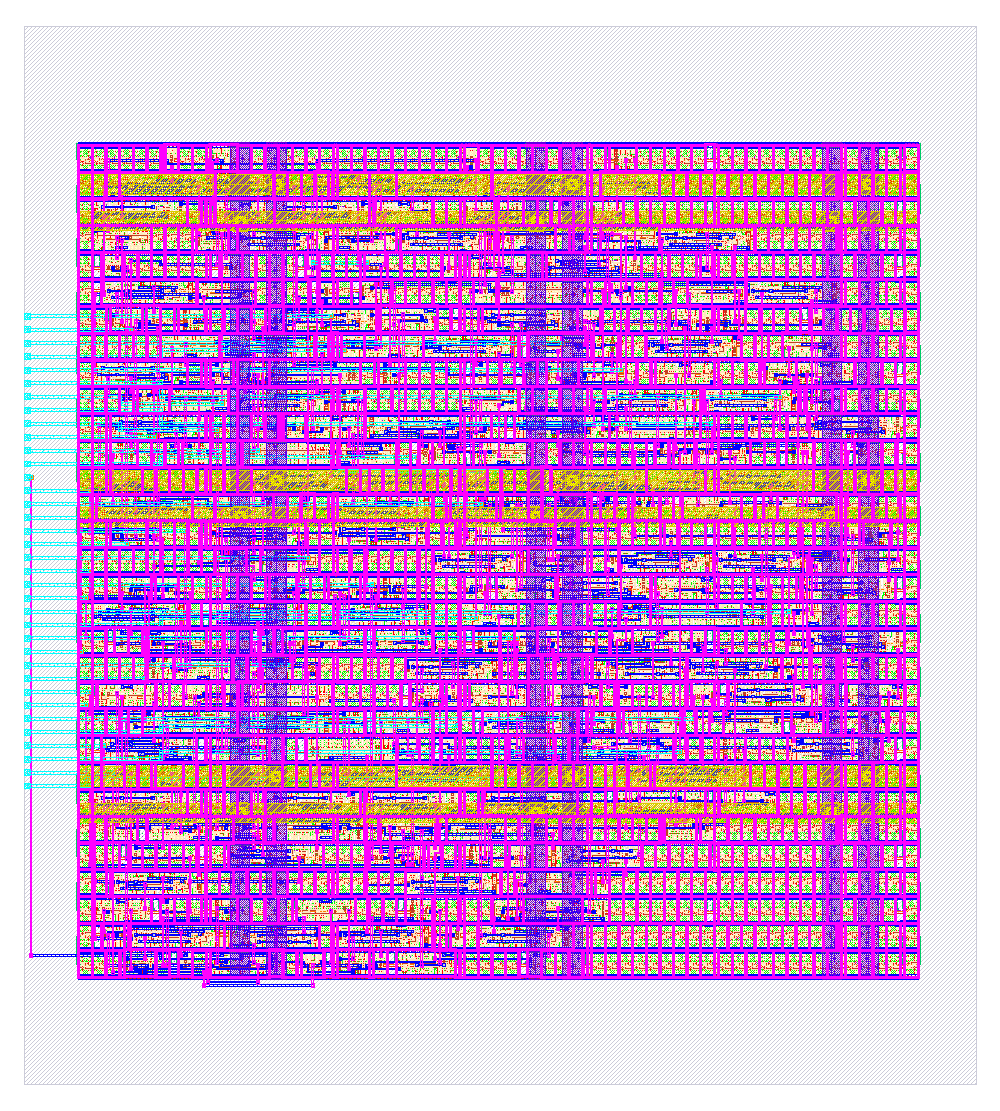

In [36]:
display(gds)

#Design Rule Checks (DRC)

In [37]:
DRC = Step.factory.get("Magic.DRC")

drc = DRC(state_in=gds.state_out)
drc.start()

─────────────────────────────────────────────── Design Rule Checks ────────────────────────────────────────────────

[16:23:17] VERBOSE  Running 'Magic.DRC' at 'librelane_run/16-magic-drc'…                               ]8;id=25263;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=996927;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:23:17] VERBOSE  Logging subprocess to 'librelane_run/16-magic-drc/magic-drc.log'…                  ]8;id=546402;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=675375;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

[INFO] Should be divided by 3 or 4

[INFO] DRC Checking DONE (/content/librelane_run/16-magic-drc/reports/drc.magic.rpt)

[INFO] Saving mag view with DRC errors (/content/librelane_run/16-magic-drc/views/spm.drc.mag)

[INFO] Saved

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/15-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/15-klayout-streamout/spm.gds'), 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__count__class:sequential_cell': 64, 'design__instance__area__class:sequential_c

#SPICE Extraction for Layout vs. Schematic Check

In [38]:
SpiceExtraction = Step.factory.get("Magic.SpiceExtraction")

spx = SpiceExtraction(state_in=drc.state_out)
spx.start()


───────────────────────────────────────────── SPICE Model Extraction ──────────────────────────────────────────────

[16:23:20] VERBOSE  Running 'Magic.SpiceExtraction' at 'librelane_run/17-magic-spiceextraction'…       ]8;id=400209;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=314502;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:23:20] VERBOSE  Logging subprocess to                                                              ]8;id=176761;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=918044;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/17-magic-spiceextraction/magic-spiceextraction.log'…                            

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

Extracting sky130_fd_sc_hd__nand3_2 into sky130_fd_sc_hd__nand3_2.ext:

Extracting sky130_fd_sc_hd__a21o_2 into sky130_fd_sc_hd__a21o_2.ext:

Extracting spm into spm.ext:

exttospice finished.

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/15-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/15-klayout-streamout/spm.gds'), 'spice': Path('/content/librelane_run/17-magic-spiceextraction/spm.spice'), 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__co

#Layout vs. Schematic (LVS)

In [39]:
LVS = Step.factory.get("Netgen.LVS")

lvs = LVS(state_in=spx.state_out)
lvs.start()

─────────────────────────────────────────────────── Netgen LVS ────────────────────────────────────────────────────

[16:23:25] VERBOSE  Running 'Netgen.LVS' at 'librelane_run/18-netgen-lvs'…                             ]8;id=873680;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=381986;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[16:23:25] VERBOSE  Logging subprocess to 'librelane_run/18-netgen-lvs/netgen-lvs.log'…                ]8;id=906383;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=476058;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Netgen 1.5.316 compiled on Tue Feb 10 11:09:08 UTC 2026

Warning: netgen command 'format' use fully-qualified name '::netgen::format'

...

Circuits match uniquely.

.

Logging to file "/content/librelane_run/18-netgen-lvs/reports/lvs.netgen.rpt" disabled

LVS Done.

{'nl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/12-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/12-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/12-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/12-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/13-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/13-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/13-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/14-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/14-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/15-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/15-klayout-streamout/spm.gds'), 'spice': Path('/content/librelane_run/17-magic-spiceextraction/spm.spice'), 'metrics': {'design__instance__count': 1344, 'design__instance__area': Decimal('7175.63'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 96.535 107.255', 'design__core__bbox': '5.52 10.88 90.62 95.2', 'design__io': 38, 'design__die__area': Decimal('10353.9'), 'design__core__area': Decimal('7175.63'), 'design__instance__count__stdcell': 394, 'design__instance__area__stdcell': Decimal('4003.84'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.557977'), 'design__instance__utilization__stdcell': Decimal('0.557977'), 'design__rows': 31, 'design__rows:unithd': 31, 'design__sites': 5735, 'design__sites:unithd': 5735, 'design__instance__count__class:inverter': 64, 'design__instance__area__class:inverter': Decimal('240.23'), 'design__instance__co